# CONFLUENCE Tutorial - 3: Lumped Basin Workflow (Tuolumne River at Yosemite)

## Introduction
This tutorial demonstrates the scaling transition from point-scale validation to basin-scale streamflow simulation using CONFLUENCE. Building on our previous tutorials with SNOTEL and FLUXNET data validation, we now advance to modeling an entire watershed as a single computational unit to generate streamflow predictions at the basin outlet, establishing the foundation for distributed hydrological modeling applications.

## Lumped Basin Modeling Philosophy
Lumped basin modeling treats the entire watershed as one homogeneous computational unit, spatially averaging all variability across the catchment. While this represents a simplification of complex spatial heterogeneity, lumped modeling provides exceptional scientific value through its computational simplicity that enables efficient implementation and rapid execution ideal for calibration and uncertainty analysis. This approach establishes baseline performance by determining whether a model can capture fundamental watershed response before adding spatial complexity, while its simplified parameter structure facilitates clear understanding of which parameters control model behavior and hydrological processes.


## Step 1: Basin-Scale Workflow Setup
Building on the point-scale modeling expertise from Tutorials 01a and 01b, we now advance to basin-scale hydrological modeling. This represents a scaling transition from process validation at individual sites to integrated watershed simulation that captures the collective hydrological response of an entire catchment.

The same CONFLUENCE architecture seamlessly handles this transition, demonstrating the framework's scalability from point validation through basin-scale prediction while maintaining reproducible workflow principles.

In [4]:
import os
# change to CONFLUENCE root directory
os.chdir('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')

In [5]:

# Import the libraries we'll need in this notebook
import sys
from pathlib import Path
import yaml
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from datetime import datetime
import xarray as xr
import numpy as np
import shutil

# Add CONFLUENCE to path
confluence_path = Path().resolve()
sys.path.append(str(confluence_path))

# Import main CONFLUENCE class
from CONFLUENCE import CONFLUENCE

# import custom utility functions
from utils.custom.calc import *
from utils.custom.plotting import *

# Set up plotting style
plt.style.use('default')
%matplotlib inline


In [6]:

# =============================================================================
# CONFIGURATION FOR SEMI-DISTRIBUTED East RIVER MODELING
# =============================================================================

# Set directory paths
CONFLUENCE_CODE_DIR = confluence_path
CONFLUENCE_DATA_DIR = Path('/scratch/dlhogan/ess-project-data/') 

# Load template configuration and customize for semi-distributed modeling
config_template_path = CONFLUENCE_CODE_DIR / 'ess-project' / '0_config_files' / 'config_Tuolumne.yaml'

with open(config_template_path, 'r') as f:
    config_dict = yaml.safe_load(f)

# Update for semi-distributed East River modeling
config_updates = {
    'CONFLUENCE_CODE_DIR': str(CONFLUENCE_CODE_DIR),
    'CONFLUENCE_DATA_DIR': str(CONFLUENCE_DATA_DIR),
    'DOMAIN_NAME': 'upperTuolumne_River_lumped',  # Update domain name
    'POUR_POINT_COORDS': '37.876155/-119.354627',	
    'BOUNDING_BOX_COORDS': '38.1/-119.7/37.7/-119.19',  # Bounding box of the domain: lat_max/lon_min/lat_min/lon_max.
    'EXPERIMENT_ID': '20251001_run_1',  # Update experiment ID
    'DOMAIN_DEFINITION_METHOD': 'lumped',    # KEY CHANGE: watershed delineation vs lumped
    'STREAM_THRESHOLD': 5000,                   # Controls number of sub-basins
    'DOMAIN_DISCRETIZATION': 'GRUs',            # Grouped Response Units
    'SPATIAL_MODE': 'Lumped',               # Changed from 'Lumped'
    'HYDROLOGICAL_MODEL': 'SUMMA',
    'ROUTING_MODEL': 'mizuRoute',
    'EXPERIMENT_TIME_START': '2020-01-01 01:00',
    'EXPERIMENT_TIME_END':  '2024-12-31 23:00',
    'CALIBRATION_PERIOD': '2020-01-01, 2021-12-31',
    'EVALUATION_PERIOD': '2022-01-01, 2024-12-31',
    'SPINUP_PERIOD': '2020-01-01, 2020-12-31',
    'TAUDEM_DIR': '/home/dlhogan/tools/src/TauDEM/bin',
    'DELINEATION_METHOD': 'TauDEM',  # Changed from 'TauDEM'
    'CATCHMENT_SHP_HRUID': 'HRU_ID',          # Updated HRU ID field
    'CATCHMENT_SHP_GRUID': 'GRU_ID',
    'SIM_REACH_ID': -1,                       # Changed to East River outlet reach ID
    'ROUTING_DELINEATION': 'lumped',        # Changed to 'lumped' or remove
    'APPLY_LAPSE_RATE': False,                 # Changed to True to apply lapse rate
}

config_dict.update(config_updates)

# Save configuration
temp_config_path = CONFLUENCE_CODE_DIR / 'ess-project' / '0_config_files' / 'config_upperTuolumne_lumped.yaml'
with open(temp_config_path, 'w') as f:
    yaml.dump(config_dict, f, default_flow_style=False, sort_keys=False)

# Initialize CONFLUENCE
confluence = CONFLUENCE(temp_config_path)

# Display configuration
print("=== Directory Configuration ===")
print(f"Code Directory: {CONFLUENCE_CODE_DIR}")
print(f"Data Directory: {CONFLUENCE_DATA_DIR}")
print("\n=== Key Configuration Settings ===")
print(f"Domain Name: {confluence.config['DOMAIN_NAME']}")
print(f"Pour Point: {confluence.config['POUR_POINT_COORDS']}")
print(f"Spatial Mode: {confluence.config['SPATIAL_MODE']}")
print(f"Model: {confluence.config['HYDROLOGICAL_MODEL']}")
print(f"Simulation Period: {confluence.config['EXPERIMENT_TIME_START']} to {confluence.config['EXPERIMENT_TIME_END']}")


2025-10-01 15:07:15 ● CONFLUENCE Logging Initialized
2025-10-01 15:07:15 ● Domain: upperTuolumne_River_lumped
2025-10-01 15:07:15 ● Experiment ID: 20251001_run_1
2025-10-01 15:07:15 ● Log Level: INFO
2025-10-01 15:07:15 ● Log File: /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/_workLog_upperTuolumne_River_lumped/confluence_general_upperTuolumne_River_lumped_20251001_150715.log
2025-10-01 15:07:15 ● Configuration logged to: /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/_workLog_upperTuolumne_River_lumped/config_upperTuolumne_River_lumped_20251001_150715.yaml
2025-10-01 15:07:15 ● Initializing VariableHandler for dataset: ERA5 and model: SUMMA
2025-10-01 15:07:16 ● CONFLUENCE initialized with config: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_config_files/config_upperTuolumne_lumped.yaml
=== Directory Configuration ===
Code Directory: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro
Data Directory: /scratch

### Model Decision & Parameter Changes

In [7]:
from utils.custom.adjust_settings import edit_localParamInfo, edit_modelDecisions
modelDecision_file = Path("/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/0_base_settings/SUMMA/modelDecisions.txt")
localParamInfo_file = Path("/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/0_base_settings/SUMMA/localParamInfo.txt")
basinParamInfo_file = Path("/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/0_base_settings/SUMMA/basinParamInfo.txt")

# Model Decision changes
modelDecision_updates = {
    'groundwatr': 'bigBuckt',  # 'bigBuckt', could use 'noXplict'
    'alb_method': 'varDecay' # change from 'varDecay' to 'conDecay'
    }

# Parameter changes - ensure you have 4 characters after the decimal
localParamInfo_updates = {
    'tempCritRain': '273.1600',
    'upperBoundtemp': '272.1600',
    'lowerBoundtemp': '274.1600',
    'albedoMinVisible': '0.3000',
    'albedoDecayRate' : '1.0d+6'
}

# Basin Parameter changes
basinParamInfo_updates = {
    "basin__aquiferHydCond" : "0.0010", # 0.0001 to 10.0000
    "basin__aquiferScaleFactor" : "3.5000", # 0.1000 to 100.0000
    "basin__aquiferBaseflowExp" : "5.0000", # 1.0000 to 10.0000
    "routingGammaShape" : "2.0000", # 2.0000 to 3.0000
    "routingGammaScale" : "1.0d+6", # 1.0000 to 5.0d+6
}

edit_modelDecisions(modelDecision_file, modelDecision_updates)
edit_localParamInfo(localParamInfo_file, localParamInfo_updates)
edit_localParamInfo(basinParamInfo_file, basinParamInfo_updates)


In [8]:
# Project Initialization
project_dir = confluence.managers['project'].setup_project()

# Create pour point
pour_point_path = confluence.managers['project'].create_pour_point()

# List created directories
print("\nCreated directories:")
for item in sorted(project_dir.iterdir()):
    if item.is_dir():
        print(f"  📁 {item.name}")

print("\nDirectory purposes:")
print("  📁 shapefiles: Domain geometry (watershed, pour points, river network)")
print("  📁 attributes: Static characteristics (elevation, soil, land cover)")
print("  📁 forcing: Meteorological inputs (precipitation, temperature)")
print("  📁 simulations: Model outputs")
print("  📁 evaluation: Performance metrics and comparisons")
print("  📁 plots: Visualizations")
print("  📁 optimisation: Calibration results")

2025-10-01 15:07:19 ● Setting up project for domain: upperTuolumne_River_lumped
2025-10-01 15:07:19 ● Project directory created at: /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped
2025-10-01 15:07:20 ● Pour point shapefile created successfully: /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/shapefiles/pour_point/upperTuolumne_River_lumped_pourPoint.shp

Created directories:
  📁 _workLog_upperTuolumne_River_lumped
  📁 attributes
  📁 forcing
  📁 optimisation
  📁 plots
  📁 settings
  📁 shapefiles

Directory purposes:
  📁 shapefiles: Domain geometry (watershed, pour points, river network)
  📁 attributes: Static characteristics (elevation, soil, land cover)
  📁 forcing: Meteorological inputs (precipitation, temperature)
  📁 simulations: Model outputs
  📁 evaluation: Performance metrics and comparisons
  📁 plots: Visualizations
  📁 optimisation: Calibration results


## Step 2: Basin Representation and Spatial Discretization Fundamentals
The transition from point-scale to basin-scale modeling requires fundamental decisions about how to represent spatial heterogeneity within the watershed. Unlike point-scale modeling where we assume uniform conditions, basin-scale modeling must address the challenge of capturing spatial variability while maintaining computational tractability and scientific interpretability.

### Scientific Context: Basin Representation Philosophy
Basin-scale hydrological modeling confronts significant spatial heterogeneity challenges that profoundly influence water cycling processes. Elevation gradients create complex patterns in temperature lapse rates, precipitation distributions, and snow line dynamics that control seasonal water storage and release. Vegetation patterns ranging from dense forest to alpine zones fundamentally alter evapotranspiration rates and interception processes. Soil variability across the landscape affects infiltration capacity, water storage potential, and drainage characteristics that determine runoff generation mechanisms. Topographic effects including slope, aspect, and drainage network configuration control flow routing and energy balance processes. Climate gradients manifest through orographic precipitation enhancement, temperature inversions, and wind pattern modifications that create substantial spatial variability in hydrological drivers.

### Representation Strategies and Discretization Approaches
Hydrological modeling addresses these spatial complexities through three primary representation strategies, each offering distinct advantages and computational trade-offs. The lumped approach treats the entire watershed as a single computational unit with spatially-averaged characteristics, providing computational efficiency and parameter interpretability while sacrificing spatial detail. Semi-distributed strategies create multiple computational units based on landscape similarity criteria such as elevation bands, soil types, or land cover classes, balancing spatial representation with computational tractability. Fully distributed approaches employ grid-based representation with explicit spatial patterns, capturing detailed heterogeneity at the cost of increased computational demands and parameter complexity.

The Grouped Response Unit (GRU) concept provides flexible spatial discretization that allows users to choose the appropriate level of complexity for their scientific objectives and computational constraints. This framework enables seamless transitions from lumped representations through increasingly detailed semi-distributed configurations, ensuring that model complexity aligns with both scientific questions and available computational resources.

In [7]:
# Check for existing data from lumped model tutorial
lumped_domain = 'Tuolumne_River'  # From Tutorial 02a
lumped_data_dir = CONFLUENCE_DATA_DIR / f'domain_{lumped_domain}_lumped'

if lumped_data_dir.exists():
    print(f"✅ Found existing data: {lumped_data_dir}")
    
    # Define reusable data categories
    reusable_data = {
        'Elevation (DEM)': lumped_data_dir / 'attributes' / 'elevation',
        'Soil Data': lumped_data_dir / 'attributes' / 'soilclass', 
        'Land Cover': lumped_data_dir / 'attributes' / 'landclass',
        'ERA5 Forcing': lumped_data_dir / 'forcing' / 'merged_data',
        # 'WSC Observations': lumped_data_dir / 'observations' / 'streamflow'
    }
    
    # Check availability and copy reusable data
    print(f"\n🔄 Copying and Adapting Reusable Data...")
    
    # Initialize CONFLUENCE first to create directory structure
    confluence = CONFLUENCE(temp_config_path)
    project_dir = confluence.managers['project'].setup_project()
    
    def copy_with_name_adaptation(src_path, dst_path, old_name, new_name):
        """Copy files with name adaptation for new domain"""
        if not src_path.exists():
            return False
            
        dst_path.parent.mkdir(parents=True, exist_ok=True)
        
        if src_path.is_dir():
            # Copy directory contents with name adaptation
            for src_file in src_path.rglob('*'):
                if src_file.is_file():
                    rel_path = src_file.relative_to(src_path)
                    # Adapt filename
                    new_filename = src_file.name.replace(old_name, new_name)
                    dst_file = dst_path / rel_path.parent / new_filename
                    dst_file.parent.mkdir(parents=True, exist_ok=True)
                    shutil.copy2(src_file, dst_file)
            return True
        elif src_path.is_file():
            # Copy single file with name adaptation
            new_filename = dst_path.name.replace(old_name, new_name)
            dst_file = dst_path.parent / new_filename
            dst_file.parent.mkdir(parents=True, exist_ok=True)
            shutil.copy2(src_path, dst_file)
            return True
        return False
    
    # Copy reusable data with appropriate naming
    for data_type, src_path in reusable_data.items():
        if src_path.exists():
            # Determine destination path
            rel_path = src_path.relative_to(lumped_data_dir)
            dst_path = project_dir / rel_path
            
            # Copy with name adaptation
            success = copy_with_name_adaptation(
                src_path, dst_path, 
                lumped_domain, config_dict['DOMAIN_NAME']
            )
            
            if success:
                print(f"   ✅ {data_type}: Copied and adapted")
            else:
                print(f"   ⚠️  {data_type}: Copy failed")
        else:
            print(f"   📋 {data_type}: Not found, will acquire fresh")
    
else:
    print(f"⚠️  No existing data found from Tutorial 02a")
    print(f"   Will acquire all data from scratch")
    
    # Initialize CONFLUENCE and create project structure
    confluence = CONFLUENCE(temp_config_path)
    project_dir = confluence.managers['project'].setup_project()

# Create pour point
pour_point_path = confluence.managers['project'].create_pour_point()


✅ Found existing data: /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped

🔄 Copying and Adapting Reusable Data...
2025-09-30 17:02:46 ● CONFLUENCE Logging Initialized
2025-09-30 17:02:46 ● Domain: upperTuolumne_River_lumped
2025-09-30 17:02:46 ● Experiment ID: 20251001_run_1
2025-09-30 17:02:46 ● Log Level: INFO
2025-09-30 17:02:46 ● Log File: /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/_workLog_upperTuolumne_River_lumped/confluence_general_upperTuolumne_River_lumped_20250930_170246.log
2025-09-30 17:02:46 ● Configuration logged to: /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/_workLog_upperTuolumne_River_lumped/config_upperTuolumne_River_lumped_20250930_170246.yaml
2025-09-30 17:02:46 ● Initializing VariableHandler for dataset: ERA5 and model: SUMMA
2025-09-30 17:02:47 ● CONFLUENCE initialized with config: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_config_files/config_upperTuolumne_lumped.yaml
202

In [9]:
# Execute attribute acquisition
# confluence.managers['data'].acquire_attributes()
print("✅ Basin-scale attribute acquisition complete")

✅ Basin-scale attribute acquisition complete


In [11]:
# Execute watershed delineation
watershed_path = confluence.managers['domain'].define_domain()
print("✅ Watershed delineation complete")

2025-10-01 15:08:17 ● Domain definition workflow starting with: lumped
2025-10-01 15:08:17 ● Starting lumped watershed delineation for upperTuolumne_River_lumped


PitRemove version 5.3.9


ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0


Input file /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/attributes/elevation/dem/domain_upperTuolumne_River_lumped_elv.tif has geographic coordinate system.
Nodata value input to create partition from file: -9999.000000
Nodata value recast to float used in partition raster: -9999.000000


This run may take on the order of 1 minutes to complete.
This estimate is very approximate. 
Run time is highly uncertain as it depends on the complexity of the input data 
and speed and memory of the computer. This estimate is based on our testing on 
a dual quad core Dell Xeon E5405 2.0GHz PC with 16GB RAM.


...

MoveOutletsToStreams version 5.3.9
Input file /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/shapefiles/tempdir/src.tif has geographic coordinate system.
Nodata value input to create partition from file: -32768.000000
Nodata value recast to int16_t used in partition raster: -32768
Input file /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/shapefiles/tempdir/p.tif has geographic coordinate system.
Nodata value input to create partition from file: -32768.000000
Nodata value recast to int16_t used in partition raster: -32768
om Total time: 0.138250
2025-10-01 15:08:22 ● Completed TauDEM step: mpirun -n 1 /home/dlhogan/tools/src/TauDEM/bin/moveoutletstostrm -p /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/shapefiles/tempdir/p.tif -src /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/shapefiles/tempdir/src.tif -o /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/shapefiles/pour_point/upperTuo

ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
This run may take on the order of 1 minutes to complete.
This estimate is very approximate. 
Run time is highly uncertain as it depends on the complexity of the input data 
and speed and memory of the computer. This estimate is based on our testing on 
a dual quad core Dell Xeon E5405 2.0GHz PC with 16GB RAM.
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: 

Gage Watershed version 5.3.9
Input file /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/shapefiles/tempdir/p.tif has geographic coordinate system.
Nodata value input to create partition from file: -32768.000000
Nodata value recast to int16_t used in partition raster: -32768
Size: 1
Read time: 0.056465
Compute time: 0.006223
Write time: 0.007091
Total time: 0.069779
2025-10-01 15:08:23 ● Completed TauDEM step: mpirun -n 1 /home/dlhogan/tools/src/TauDEM/bin/gagewatershed -p /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/shapefiles/tempdir/p.tif -o /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/shapefiles/tempdir/om.shp -gw /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/shapefiles/tempdir/watershed.tif -id /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/shapefiles/tempdir/watershed_id.txt


ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
ERROR 1: /home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/gdalplugins/../libgdal.so.37: undefined symbol: jpeg12_write_raw_data, version LIBJPEG_8.0
This run may take on the order of 1 minutes to complete.
This estimate is very approximate. 
Run time is highly uncertain as it depends on the complexity of the input data 
and speed and memory of the computer. This estimate is based on our testing on 
a dual quad core Dell Xeon E5405 2.0GHz PC with 16GB RAM.


2025-10-01 15:08:23 ● Removed temporary file: /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/shapefiles/river_basins/upperTuolumne_River_lumped_riverBasins_lumped_temp.dbf
2025-10-01 15:08:23 ● Removed temporary file: /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/shapefiles/river_basins/upperTuolumne_River_lumped_riverBasins_lumped_temp.shp
2025-10-01 15:08:23 ● Removed temporary file: /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/shapefiles/river_basins/upperTuolumne_River_lumped_riverBasins_lumped_temp.shx
2025-10-01 15:08:23 ● Filtered watershed shapefile created at: /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/shapefiles/river_basins/upperTuolumne_River_lumped_riverBasins_lumped.shp
2025-10-01 15:08:24 ● Updated watershed shapefile at: /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/shapefiles/river_basins/upperTuolumne_River_lumped_riverBasins_lumped.shp
2025-10-01 15:08:24 

In [12]:
# Execute domain discretization
# confluence.managers['domain'].discretize_domain()
print("✅ Domain discretization complete")


✅ Domain discretization complete


## VISUALIZATION AND ANALYSIS OF BASIN REPRESENTATION


📋 Basin Characteristics:
   Watershed area: 190.4 km²
   Number of GRUs: 1
   Average GRU size: 190.4 km²

🗺️  Creating basin representation visualization...


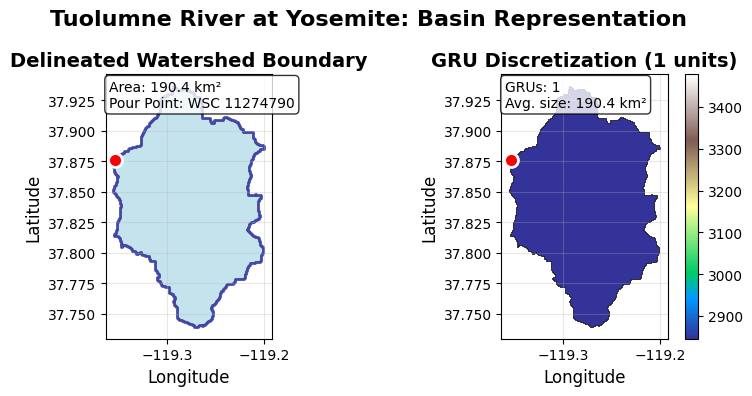

In [13]:
# Load spatial data
hru_path = str(Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / 'shapefiles' / 'catchment' / f"{config_dict['DOMAIN_NAME']}_HRUs_{config_dict['DOMAIN_DISCRETIZATION']}.shp")
watershed_gdf = gpd.read_file(str(watershed_path[1]))
hru_gdf = gpd.read_file(hru_path)
pour_point_gdf = gpd.read_file(pour_point_path)

# Project to appropriate CRS for area calculations
# For Tuolumne River at Yosemite (Alberta), UTM Zone 11N is appropriate
target_crs = 'EPSG:32611'  # UTM Zone 11N
watershed_projected = watershed_gdf.to_crs(target_crs)
hru_projected = hru_gdf.to_crs(target_crs)

print(f"\n📋 Basin Characteristics:")
total_area_m2 = watershed_projected.geometry.area.sum()
total_area_km2 = total_area_m2 / 1e6
print(f"   Watershed area: {total_area_km2:.1f} km²")
print(f"   Number of GRUs: {len(hru_gdf)}")
print(f"   Average GRU size: {total_area_km2/len(hru_gdf):.1f} km²")

# Display HRU characteristics if available
if 'elevation' in hru_gdf.columns:
    print(f"   Elevation range: {hru_gdf['elevation'].min():.0f}m to {hru_gdf['elevation'].max():.0f}m")
if 'slope' in hru_gdf.columns:
    print(f"   Slope range: {hru_gdf['slope'].min():.1f}° to {hru_gdf['slope'].max():.1f}°")

# Create comprehensive visualization
print(f"\n🗺️  Creating basin representation visualization...")
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

# Left plot: Watershed boundary and pour point (use original CRS for plotting)
ax1 = axes[0]
watershed_gdf.plot(ax=ax1, facecolor='lightblue', edgecolor='navy', 
                  linewidth=2, alpha=0.7)
pour_point_gdf.plot(ax=ax1, color='red', markersize=100, marker='o',
                   edgecolor='white', linewidth=2, zorder=5)
ax1.set_title('Delineated Watershed Boundary', fontsize=14, fontweight='bold')
ax1.set_xlabel('Longitude', fontsize=12)
ax1.set_ylabel('Latitude', fontsize=12)
ax1.grid(True, alpha=0.3)

# Add area annotation
ax1.text(0.02, 0.98, f'Area: {total_area_km2:.1f} km²\nPour Point: WSC {config_dict["STATION_ID"]}',
         transform=ax1.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.3'))

# Right plot: HRU discretization
ax2 = axes[1]
# Color HRUs by elevation if available, otherwise by area (using projected areas)
if 'elev_mean' in hru_gdf.columns:
    hru_gdf.plot(ax=ax2, column='elev_mean', cmap='terrain', 
                edgecolor='black', linewidth=0.5, legend=True)
    colorbar_label = 'Elevation (m)'
else:
    # Use projected geometries for area calculation
    hru_areas_km2 = hru_projected.geometry.area / 1e6
    hru_gdf.plot(ax=ax2, column=hru_areas_km2, cmap='viridis',
                edgecolor='black', linewidth=0.5, legend=True) 
    colorbar_label = 'Area (km²)'

pour_point_gdf.plot(ax=ax2, color='red', markersize=100, marker='o',
                   edgecolor='white', linewidth=2, zorder=5)
ax2.set_title(f'GRU Discretization ({len(hru_gdf)} units)', fontsize=14, fontweight='bold')
ax2.set_xlabel('Longitude', fontsize=12)
ax2.set_ylabel('Latitude', fontsize=12)
ax2.grid(True, alpha=0.3)

# Add discretization info
ax2.text(0.02, 0.98, f'GRUs: {len(hru_gdf)}\nAvg. size: {total_area_km2/len(hru_gdf):.1f} km²',
         transform=ax2.transAxes, fontsize=10, verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.3'))

plt.suptitle(f'Tuolumne River at Yosemite: Basin Representation', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 3: Data Pipeline for Basin-Scale Streamflow Modeling
The same model-agnostic preprocessing framework now scales from point validation to basin-scale streamflow simulation. The core philosophy remains unchanged—standardized, quality-controlled data products—but the spatial context shifts from single locations to integrated watershed responses

In [13]:
# Execute streamflow data processing
# confluence.managers['data'].process_observed_data()
print("✅ Streamflow data processing complete")

# Execute forcing acquisition (commented for demonstration)
# confluence.managers['data'].acquire_forcings()
print("✅ forcing acquisition complete (simulated)")

✅ Streamflow data processing complete
✅ forcing acquisition complete (simulated)


In [ ]:
# Execute model-agnostic preprocessing
# confluence.managers['data'].run_model_agnostic_preprocessing()
print("✅ Model-agnostic preprocessing complete")

2025-09-30 17:07:36 ● Starting model-agnostic preprocessing
2025-09-30 17:07:36 ● Running geospatial statistics
2025-09-30 17:07:36 ● Starting geospatial statistics calculation


2025-09-30 17:07:36 ● Calculating soil statistics
2025-09-30 17:07:36 ● Soil raster CRS: EPSG:4326
2025-09-30 17:07:36 ● Catchment shapefile CRS: EPSG:4326
2025-09-30 17:07:36 ● CRS match - no reprojection needed
2025-09-30 17:07:36 ● Soil statistics saved to /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/shapefiles/catchment_intersection/with_soilgrids/catchment_with_soilclass.shp
2025-09-30 17:07:36 ● Calculating land statistics
2025-09-30 17:07:36 ● Land raster CRS: EPSG:4326
2025-09-30 17:07:36 ● Catchment shapefile CRS: EPSG:4326
2025-09-30 17:07:36 ● CRS match - no reprojection needed
2025-09-30 17:07:36 ● Land statistics saved to /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/shapefiles/catchment_intersection/with_landclass/catchment_with_landclass.shp
2025-09-30 17:07:36 ● Calculating elevation statistics
2025-09-30 17:07:36 ● DEM CRS: EPSG:4326
2025-09-30 17:07:36 ● Catchment shapefile CRS: EPSG:4326
2025-09-30 17:07:36 ● CRS match - n

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/easymore/remapper.py:521: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  shp_int.to_file(self.temp_dir+self.case_name+'_intersected_shapefile.shp') # save the intersected files
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'S_1_gru_to_seg' to 'S_1_gru_to'
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'S_1_GRU_area' to 'S_1_GRU_ar'
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'S_1_hru_type' to 'S_1_hru_ty'
  ogr_write(
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laund

Ended at date and time 2025-09-30 17:07:38.906822
It took 1.284048 seconds to finish creating of the remapping file
---------------------------
------REMAPPING------
netcdf output file will be compressed at level 4
Remapping /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/forcing/merged_data/ERA5_merged_201601.nc to /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/forcing/basin_averaged_data/upperTuolumne_River_lumped_ERA5_remapped_ERA5_merged_201601.nc 
Started at date and time 2025-09-30 17:07:38.983695 
Ended at date and time 2025-09-30 17:07:56.120503 
It took 17.136808 seconds to finish the remapping of variable(s) 
---------------------
---------------------
17:07:56 ● ✓ Successfully processed ERA5_merged_201601.nc (1/108)
2025-09-30 17:07:56 ● Processing file 2/108: ERA5_merged_201602.nc
2025-09-30 17:07:56 ● Checking CRS for forcing_ERA5.shp: EPSG:4326
2025-09-30 17:07:56 ● Shapefile forcing_ERA5.shp already in WGS84
2025-09-30 17:07:56 ● Check

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/easymore/remapper.py:939: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  lat_value = np.array(ncid.variables[self.var_lat])
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/easymore/remapper.py:940: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  lon_value = np.array(ncid.variables[self.var_lon])
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/easymor

...

Ended at date and time 2025-09-30 17:37:06.739246
It took 0.140187 seconds to finish creating of the remapping file
---------------------------
------REMAPPING------
netcdf output file will be compressed at level 4
Remapping /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/forcing/merged_data/ERA5_merged_202410.nc to /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/forcing/basin_averaged_data/upperTuolumne_River_lumped_ERA5_remapped_ERA5_merged_202410.nc 
Started at date and time 2025-09-30 17:37:06.769706 
Ended at date and time 2025-09-30 17:37:24.201064 
It took 17.431358 seconds to finish the remapping of variable(s) 
---------------------
---------------------
17:37:24 ● ✓ Successfully processed ERA5_merged_202410.nc (106/108)
2025-09-30 17:37:24 ● Processing file 107/108: ERA5_merged_202411.nc
2025-09-30 17:37:24 ● Checking CRS for forcing_ERA5.shp: EPSG:4326
2025-09-30 17:37:24 ● Shapefile forcing_ERA5.shp already in WGS84
2025-09-30 17:37:24 ● C

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/easymore/remapper.py:939: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  lat_value = np.array(ncid.variables[self.var_lat])
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/easymore/remapper.py:940: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  lon_value = np.array(ncid.variables[self.var_lon])
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/easymor

Ended at date and time 2025-09-30 17:37:24.466633
It took 0.174276 seconds to finish creating of the remapping file
---------------------------
------REMAPPING------
netcdf output file will be compressed at level 4
Remapping /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/forcing/merged_data/ERA5_merged_202411.nc to /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/forcing/basin_averaged_data/upperTuolumne_River_lumped_ERA5_remapped_ERA5_merged_202411.nc 
Started at date and time 2025-09-30 17:37:24.504620 
Ended at date and time 2025-09-30 17:37:40.710176 
It took 16.205556 seconds to finish the remapping of variable(s) 
---------------------
---------------------
17:37:40 ● ✓ Successfully processed ERA5_merged_202411.nc (107/108)
2025-09-30 17:37:40 ● Processing file 108/108: ERA5_merged_202412.nc
2025-09-30 17:37:40 ● Checking CRS for forcing_ERA5.shp: EPSG:4326
2025-09-30 17:37:40 ● Shapefile forcing_ERA5.shp already in WGS84
2025-09-30 17:37:40 ● C

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/easymore/remapper.py:939: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  lat_value = np.array(ncid.variables[self.var_lat])
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/easymore/remapper.py:940: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  lon_value = np.array(ncid.variables[self.var_lon])
/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/easymor

------REMAPPING------
netcdf output file will be compressed at level 4
Remapping /scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/forcing/merged_data/ERA5_merged_202412.nc to /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/forcing/basin_averaged_data/upperTuolumne_River_lumped_ERA5_remapped_ERA5_merged_202412.nc 
Started at date and time 2025-09-30 17:37:40.976918 
Ended at date and time 2025-09-30 17:37:57.436092 
It took 16.459174 seconds to finish the remapping of variable(s) 
---------------------
---------------------
17:37:57 ● ✓ Successfully processed ERA5_merged_202412.nc (108/108)
2025-09-30 17:37:57 ● Processing complete: 108 files processed successfully out of 108
2025-09-30 17:37:57 ● Total files processed or skipped: 108 out of 108
2025-09-30 17:37:57 ● Forcing remapping process completed
2025-09-30 17:37:57 ● Forcing data resampling process completed
2025-09-30 17:37:57 ● Model-agnostic preprocessing completed successfully
✅ Model-agnosti

In [15]:
# Execute model-specific preprocessing
confluence.managers['model'].preprocess_models()
print("✅ Basin-scale model configuration complete")

2025-09-30 17:39:46 ● Starting model-specific preprocessing
2025-09-30 17:39:46 ● Starting SUMMA spatial preprocessing
2025-09-30 17:39:46 ● Starting memory-efficient temperature lapse rate and data step application
2025-09-30 17:39:46 ● Converting /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/shapefiles/catchment_intersection/with_forcing/upperTuolumne_River_lumped_ERA5_intersected_shapefile.shp to CSV format
2025-09-30 17:39:46 ● Successfully created /scratch/dlhogan/ess-project-data/domain_upperTuolumne_River_lumped/shapefiles/catchment_intersection/with_forcing/upperTuolumne_River_lumped_ERA5_intersected_shapefile.csv
2025-09-30 17:39:48 ● Loading topology data...
2025-09-30 17:39:48 ● Loaded topology data: 2 rows, 0.02 MB
2025-09-30 17:39:48 ● Found 108 forcing files to process
2025-09-30 17:39:48 ● Pre-calculating lapse rate corrections...
2025-09-30 17:39:48 ● Prepared lapse corrections for 1 HRUs
2025-09-30 17:39:48 ● Processing files in batches of 100
202

In [12]:
# open the dem 
dem_path = str(Path(config_dict['CONFLUENCE_DATA_DIR']) / f"domain_{config_dict['DOMAIN_NAME']}" / 'attributes' / 'elevation' / "dem" / "domain_Tuolumne_River_lumped_elv.tif")

# using rasterio open the dem
import rasterio
with rasterio.open(dem_path) as dem_src:
    dem_data = dem_src.read(1)  # Read the first band
    dem_transform = dem_src.transform
    dem_crs = dem_src.crs

# calculate the mean elevation
mean_elevation = np.nanmean(dem_data)

# adjust temperature by difference between mean dem elevation and mean hru elevation
mean_hru_elevation = hru_gdf['elev_mean'].mean()
elevation_difference = mean_hru_elevation - mean_elevation
lapse_rate = 6.5 / 1000  # °C per meter
temperature_adjustment = elevation_difference * lapse_rate

# winter adjustment (Jan - May)
monthly_adjustment = {
    1: 1.0,  # January
    2: 1.0,  # February
    3: 1.0,  # March
    4: 1.0,  # April
    5: 1.0,  # May
    6: 0.0,  # June
    7: -1.0,  # July
    8: -1.0,  # August
    9: -1.0,  # September
    10: -1.0, # October
    11: -1.0, # November
    12: 0.0  # December
}

In [13]:
file_list = list(Path(config_dict['CONFLUENCE_DATA_DIR']).glob(f"domain_{config_dict['DOMAIN_NAME']}/forcing/forcing_noTadjust/{config_dict['DOMAIN_NAME']}_ERA5_remapped_ERA5_merged_*.nc"))
file_list = sorted(file_list)
for file in file_list:
    ds = xr.open_dataset(str(file))
    # adjust temperature
    ds['airtemp'] = ds['airtemp'] + temperature_adjustment
    # determe additional monthly temperature adjustment
    monthlyTempAdjustment = monthly_adjustment[ds['airtemp'].time.dt.month.values[0]]
    ds['airtemp'] = ds['airtemp'] + monthlyTempAdjustment
    # adjust precipitation
    ds['pptrate'] = ds['pptrate'] * 0.90  # Example: decrease precipitation by 10%
    # recalculate incoming longwave radiation using empirical formula
    ds['LWRadAtm'] = emperical_lw_dilley_obrien(ds['airtemp'], ds['spechum'], ds['airpres'])
    # save the modified dataset back to new file
    adjusted_file_path = str(file).replace("forcing_noTadjust", "SUMMA_input")
    ds.to_netcdf(adjusted_file_path)
    ds.close()

## Step 4: Streamlined Basin-Scale Model Execution
The same SUMMA process-based physics now scales from point validation to integrated basin simulation, but with the critical addition of streamflow routing. This represents a fundamental modeling advancement: from isolated vertical processes to coupled vertical-horizontal water transport that generates streamflow at the basin outlet.

In [15]:
# Execute the integrated model system
confluence.managers['model'].run_models()
print("✅ Basin-scale integrated simulation complete")

2025-09-23 16:42:07 ● Starting model runs
2025-09-23 16:42:07 ● Running model: SUMMA
2025-09-23 16:42:07 ● Starting SUMMA run


2025-09-23 16:43:22 ● SUMMA run completed successfully
✅ Basin-scale integrated simulation complete


#### Step 4b: Model Calibration Optimization

In [ ]:
confluence.managers['optimization'].calibrate_model()

2025-09-26 11:58:33 ● Starting model calibration
2025-09-26 11:58:33 ● Using DE optimization
2025-09-26 11:58:33 ● Using spinup + calibration period: 2017-01-01 01:00 to 2018-12-31 23:00
2025-09-26 11:58:33 ● Starting DE optimization for streamflow calibration
2025-09-26 11:58:33 ● Target metric: KGE
2025-09-26 11:58:33 ● Max iterations: 10
2025-09-26 11:58:33 ● Running DE algorithm
2025-09-26 11:58:33 ● Initializing DE population
2025-09-26 11:58:33 ● Evaluating initial population...


2025-09-26 11:59:03 ● SUMMA simulation failed with exit code 1
2025-09-26 11:59:04 ● SUMMA simulation failed with exit code 1
2025-09-26 12:01:05 ● SUMMA simulation failed with exit code 1
2025-09-26 12:01:35 ● SUMMA simulation failed with exit code 1
2025-09-26 12:01:35 ● SUMMA simulation failed with exit code 1
2025-09-26 12:01:36 ● SUMMA simulation failed with exit code 1
2025-09-26 12:02:06 ● SUMMA simulation failed with exit code 1
2025-09-26 12:02:36 ● SUMMA simulation failed with exit code 1
2025-09-26 12:04:05 ● SUMMA simulation failed with exit code 1
2025-09-26 12:04:37 ● SUMMA simulation failed with exit code 1
2025-09-26 12:07:05 ● SUMMA simulation failed with exit code 1
2025-09-26 12:08:05 ● Initial population evaluated. Best score: 0.810654


/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/numpy/_core/_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


2025-09-26 12:10:03 ● SUMMA simulation failed with exit code 1
2025-09-26 12:12:03 ● SUMMA simulation failed with exit code 1
2025-09-26 12:13:02 ● SUMMA simulation failed with exit code 1
2025-09-26 12:13:02 ● SUMMA simulation failed with exit code 1
2025-09-26 12:16:45 ● SUMMA simulation failed with exit code 1
2025-09-26 12:17:15 ● SUMMA simulation failed with exit code 1
2025-09-26 12:18:16 ● SUMMA simulation failed with exit code 1
2025-09-26 12:25:26 ● SUMMA simulation failed with exit code 1
2025-09-26 12:25:55 ● Gen   1/10: Best=0.810654, Improvements=16/30 [1070.1s]


/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/numpy/_core/_methods.py:191: RuntimeWarning: invalid value encountered in subtract
  x = asanyarray(arr - arrmean)


2025-09-26 12:32:46 ● SUMMA simulation failed with exit code 1
2025-09-26 12:33:46 ● SUMMA simulation failed with exit code 1
2025-09-26 12:43:43 ● SUMMA simulation failed with exit code 1
2025-09-26 12:45:11 ● Gen   2/10: Best=0.810654, Improvements=12/30 [1156.2s]
2025-09-26 12:45:12 ● SUMMA simulation failed with exit code 1
2025-09-26 12:51:17 ● SUMMA simulation failed with exit code 1
2025-09-26 12:51:47 ● SUMMA simulation failed with exit code 1
2025-09-26 13:06:59 ● SUMMA simulation failed with exit code 1


## Step 5: Streamflow Evaluation and Basin Performance Assessment


 Streamflow Performance Assessment...
   Evaluation period: 2017-07-01 00:59:59.999986688 to 2021-12-31 23:00:00.000013312
   Duration: 1644 days
   Valid paired observations: 1644 days

📈 Streamflow Performance Metrics:
   📊 RMSE: 12.88 m³/s
   📊 Bias: -0.72 m³/s (-6.0%)
   📊 MAE: 6.61 m³/s
   📊 Correlation (r): 0.819
   📊 Nash-Sutcliffe (NSE): 0.587
   📊 Kling-Gupta (KGE): 0.782

🌊 Hydrologic Signature Analysis:
   High flows (Q95): Obs=53.8, Sim=72.2 m³/s
   Low flows (Q05): Obs=0.2, Sim=0.0 m³/s
   Peak flow timing: Obs=Month 5, Sim=Month 5


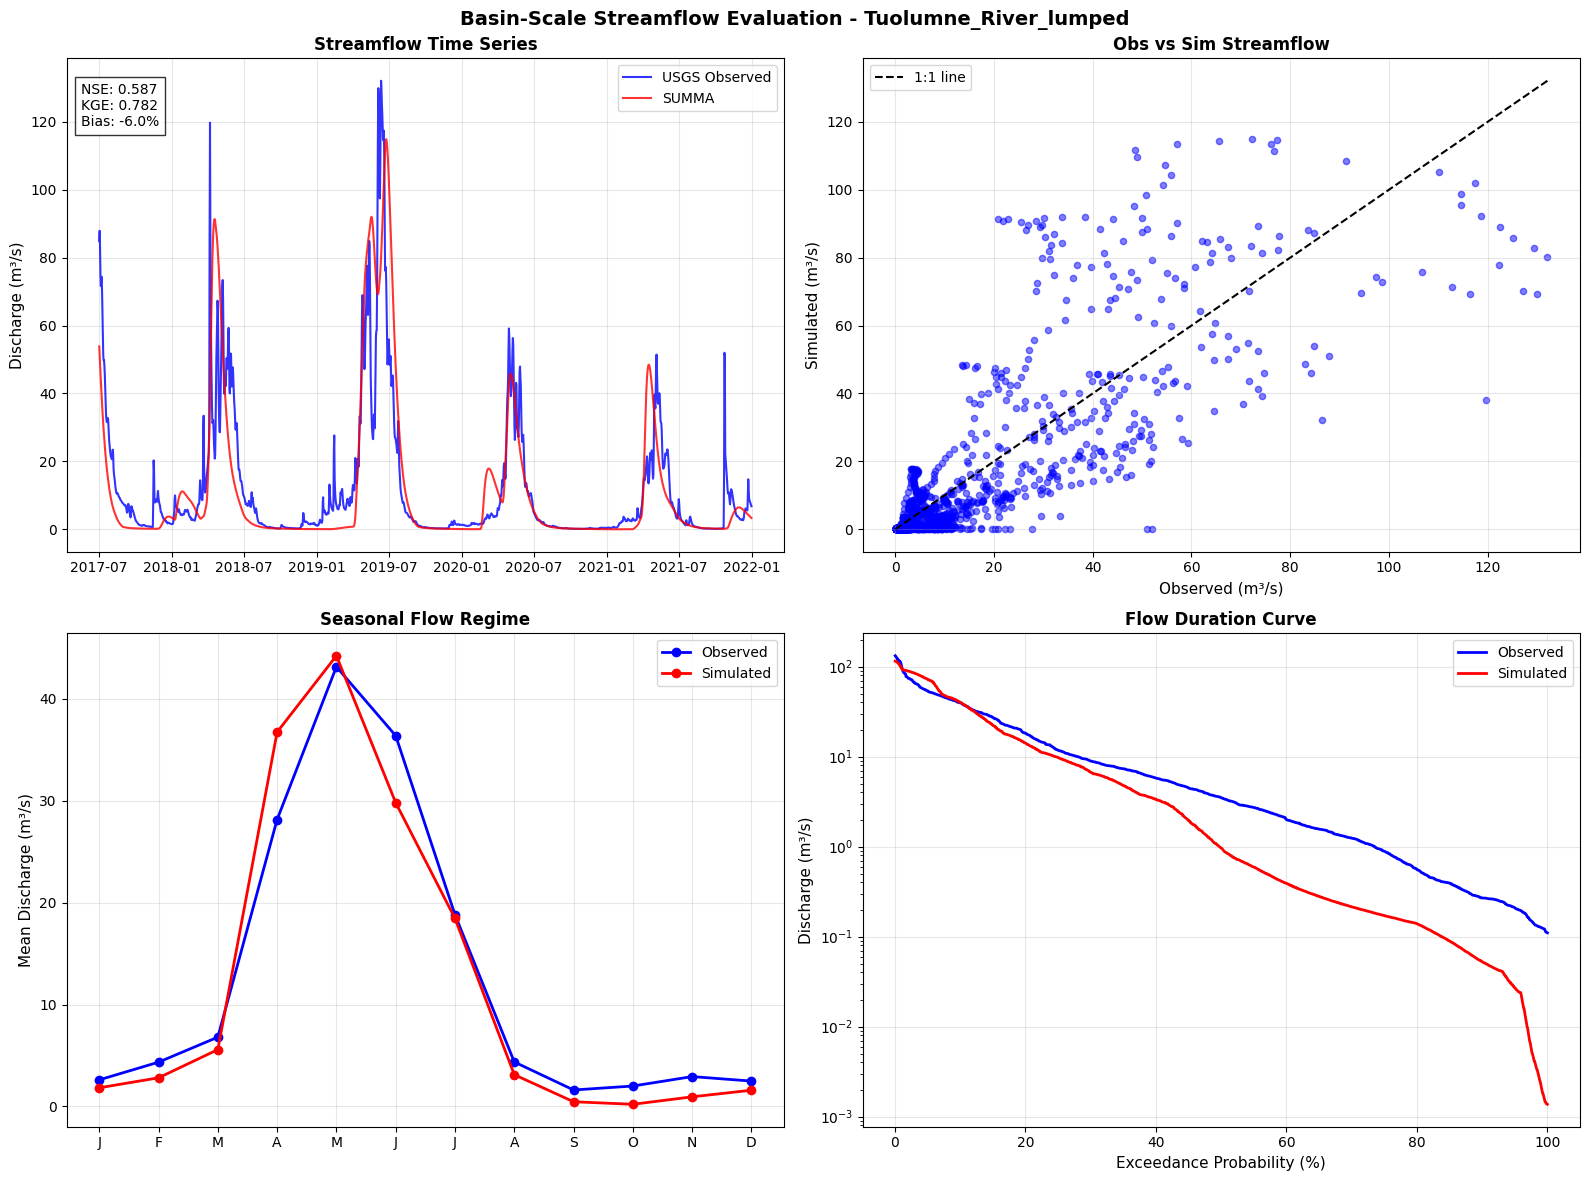

In [16]:
# Load observed streamflow data
obs_path = project_dir / "observations" / "streamflow" / "preprocessed" / f"{config_dict['DOMAIN_NAME']}_streamflow_processed.csv"
obs_df = pd.read_csv(obs_path, parse_dates=['datetime'])
obs_df.set_index('datetime', inplace=True)
    
# Load simulated streamflow from mizuRoute
summa_dir = project_dir / "simulations" / config_dict['EXPERIMENT_ID'] / "SUMMA"
routing_dir = project_dir / "simulations" / config_dict['EXPERIMENT_ID'] / "mizuRoute"
routing_files = list(routing_dir.glob("*.nc"))

if routing_files:
    # Load mizuRoute output
    routing_ds = xr.open_dataset(routing_files[0])
    
    # Extract streamflow variable (typically IRFroutedRunoff)
    sim_streamflow = routing_ds['IRFroutedRunoff']
    sim_df = sim_streamflow.to_pandas()    
    routing_ds.close()

else:
    sim_ds = xr.open_dataset(list(summa_dir.glob("*_timestep.nc"))[0])
    shp_file = gpd.read_file(str(project_dir / "shapefiles" / "catchment" / f"{config_dict['DOMAIN_NAME']}_HRUs_{config_dict['DOMAIN_DISCRETIZATION']}.shp"))
    shp_area = shp_file['GRU_area'].values[1]
    sim_ds['averageRoutedRunoff'] = sim_ds['averageRoutedRunoff'] * shp_area
    sim_streamflow = sim_ds['averageRoutedRunoff']    
    sim_df = sim_streamflow.to_pandas()
    
    sim_ds.close()

# =============================================================================
# STREAMFLOW PERFORMANCE EVALUATION
# =============================================================================

print(f"\n Streamflow Performance Assessment...")

# Align data to common period
start_date = max(obs_df.index.min(), sim_df.index.min())
end_date = min(obs_df.index.max(), sim_df.index.max())

# Skip initial spinup period
start_date = start_date + pd.DateOffset(months=6)

print(f"   Evaluation period: {start_date} to {end_date}")
print(f"   Duration: {(end_date - start_date).days} days")

# Filter to common period and resample to daily
obs_daily = obs_df['discharge_cms'].resample('D').mean().loc[start_date:end_date]
sim_daily = sim_df.resample('D').mean().loc[start_date:end_date]

# Ensure sim_daily is a Series (in case it's a DataFrame with one column)
if isinstance(sim_daily, pd.DataFrame):
    if sim_daily.shape[1] == 1:
        sim_daily = sim_daily.iloc[:, 0]  # Take the first (and likely only) column
    else:
        print(f"⚠️  sim_daily has {sim_daily.shape[1]} columns. Using the first column.")
        print(f"   Available columns: {list(sim_daily.columns)}")
        sim_daily = sim_daily.iloc[:, 0]

# Remove any remaining NaN values
valid_mask = ~(obs_daily.isna() | sim_daily.isna())
obs_valid = obs_daily[valid_mask]
sim_valid = sim_daily[valid_mask]    
print(f"   Valid paired observations: {len(obs_valid)} days")

# Calculate comprehensive performance metrics
print(f"\n📈 Streamflow Performance Metrics:")

# Basic statistics
rmse = np.sqrt(((obs_valid - sim_valid) ** 2).mean())
bias = (sim_valid - obs_valid).mean()
mae = np.abs(obs_valid - sim_valid).mean()

# Relative metrics
pbias = 100 * bias / obs_valid.mean()

# Nash-Sutcliffe Efficiency
nse = 1 - ((obs_valid - sim_valid) ** 2).sum() / ((obs_valid - obs_valid.mean()) ** 2).sum()

# Kling-Gupta Efficiency  
r = obs_valid.corr(sim_valid)
alpha = sim_valid.std() / obs_valid.std()
beta = sim_valid.mean() / obs_valid.mean()
kge = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

# Display performance metrics
print(f"   📊 RMSE: {rmse:.2f} m³/s")
print(f"   📊 Bias: {bias:+.2f} m³/s ({pbias:+.1f}%)")
print(f"   📊 MAE: {mae:.2f} m³/s")
print(f"   📊 Correlation (r): {r:.3f}")
print(f"   📊 Nash-Sutcliffe (NSE): {nse:.3f}")
print(f"   📊 Kling-Gupta (KGE): {kge:.3f}")

# Hydrologic signature analysis
print(f"\n🌊 Hydrologic Signature Analysis:")

# Flow statistics
obs_q95 = obs_valid.quantile(0.95)  # High flows
sim_q95 = sim_valid.quantile(0.95)
obs_q05 = obs_valid.quantile(0.05)  # Low flows  
sim_q05 = sim_valid.quantile(0.05)

print(f"   High flows (Q95): Obs={obs_q95:.1f}, Sim={sim_q95:.1f} m³/s")
print(f"   Low flows (Q05): Obs={obs_q05:.1f}, Sim={sim_q05:.1f} m³/s")

# Seasonal timing
obs_monthly = obs_valid.groupby(obs_valid.index.month).mean()
sim_monthly = sim_valid.groupby(sim_valid.index.month).mean()
peak_month_obs = obs_monthly.idxmax()
peak_month_sim = sim_monthly.idxmax()

print(f"   Peak flow timing: Obs=Month {peak_month_obs}, Sim=Month {peak_month_sim}")

# =============================================================================
# STREAMFLOW VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Time series comparison (top left)
ax1 = axes[0, 0]
ax1.plot(obs_valid.index, obs_valid.values, 'b-', 
         label='USGS Observed', linewidth=1.5, alpha=0.8)
ax1.plot(sim_valid.index, sim_valid.values, 'r-', 
         label='SUMMA', linewidth=1.5, alpha=0.8)

ax1.set_ylabel('Discharge (m³/s)', fontsize=11)
ax1.set_title('Streamflow Time Series', fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add performance metrics
metrics_text = f'NSE: {nse:.3f}\nKGE: {kge:.3f}\nBias: {pbias:+.1f}%'
ax1.text(0.02, 0.95, metrics_text, transform=ax1.transAxes,
         bbox=dict(facecolor='white', alpha=0.8), fontsize=10, verticalalignment='top')

# Scatter plot (top right)
ax2 = axes[0, 1]
ax2.scatter(obs_valid, sim_valid, alpha=0.5, c='blue', s=20)
max_val = max(obs_valid.max(), sim_valid.max())
ax2.plot([0, max_val], [0, max_val], 'k--', label='1:1 line')
ax2.set_xlabel('Observed (m³/s)', fontsize=11)
ax2.set_ylabel('Simulated (m³/s)', fontsize=11)
ax2.set_title('Obs vs Sim Streamflow', fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Monthly climatology (bottom left)
ax3 = axes[1, 0]
months = range(1, 13)
month_names = ['J', 'F', 'M', 'A', 'M', 'J', 'J', 'A', 'S', 'O', 'N', 'D']

ax3.plot(months, obs_monthly.values, 'o-', label='Observed', 
         color='blue', linewidth=2, markersize=6)
ax3.plot(months, sim_monthly.values, 'o-', label='Simulated', 
         color='red', linewidth=2, markersize=6)

ax3.set_xticks(months)
ax3.set_xticklabels(month_names)
ax3.set_ylabel('Mean Discharge (m³/s)', fontsize=11)
ax3.set_title('Seasonal Flow Regime', fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Flow duration curve (bottom right)
ax4 = axes[1, 1]

# Calculate exceedance probabilities
obs_sorted = obs_valid.sort_values(ascending=False)
sim_sorted = sim_valid.sort_values(ascending=False)
obs_ranks = np.arange(1., len(obs_sorted) + 1) / len(obs_sorted) * 100
sim_ranks = np.arange(1., len(sim_sorted) + 1) / len(sim_sorted) * 100

ax4.semilogy(obs_ranks, obs_sorted, 'b-', label='Observed', linewidth=2)
ax4.semilogy(sim_ranks, sim_sorted, 'r-', label='Simulated', linewidth=2)

ax4.set_xlabel('Exceedance Probability (%)', fontsize=11)
ax4.set_ylabel('Discharge (m³/s)', fontsize=11)
ax4.set_title('Flow Duration Curve', fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.suptitle(f'Basin-Scale Streamflow Evaluation - {config_dict["DOMAIN_NAME"]}',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
tuolumne_meadows = pd.read_csv("/scratch/dlhogan/ess-project-data/domain_Tuolumne_River_lumped/observations/snow/TUM_TUOLUMNE_MEADOWS_cdec_obs.csv", parse_dates=['datetime'], index_col='datetime')
tuolumne_meadows = tuolumne_meadows.loc['2017-01-01':'2022-01-01']

Monthly bias (SUMMA - TUOLUMNE MEADOWS): [ 0.62488168  0.10896706 -0.00737083 -0.27030783 -0.19166109  0.09137705
 -0.05049681  0.37244817  0.63101709  0.08023818 -0.55777821  0.00404426]


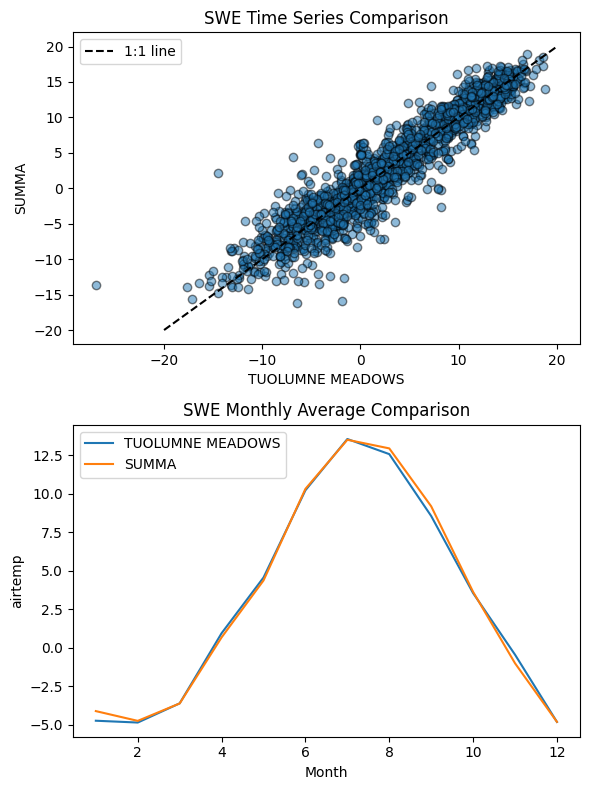

In [17]:
tuolumne_meadows_temp =((tuolumne_meadows['AIR TEMP'] - 32) * 5/9)
tuolumne_meadows_temp = tuolumne_meadows_temp[(tuolumne_meadows_temp > -50) & (tuolumne_meadows_temp < 50)]
tuolumne_meadows_temp_monthly = tuolumne_meadows_temp.groupby(tuolumne_meadows_temp.index.month).mean()

sim_ds_airtemp = sim_ds['airtemp'].resample(time='D').mean().sel(time=slice('2017-01-01','2022-01-01')).squeeze() - 273.16
# plot timeseries
fig, axs = plt.subplots(ncols=1, nrows=2, tight_layout=True, figsize=(6,8))
axs[0].scatter(tuolumne_meadows_temp.values, sim_ds_airtemp.values, alpha=0.5, ec='k')
axs[0].plot([-20,20], [-20,20], 'k--', label='1:1 line')
axs[0].legend()
axs[0].set_xlabel('TUOLUMNE MEADOWS')
axs[0].set_ylabel('SUMMA')
axs[0].set_title("SWE Time Series Comparison")

# plot monthly average comparison
tuolumne_meadows_temp_monthly.plot(ax=axs[1], label='TUOLUMNE MEADOWS')
sim_ds_airtemp.groupby('time.month').mean().plot(ax=axs[1], label='SUMMA')
axs[1].legend()
axs[1].set_xlabel('Month')
axs[1].set_title("SWE Monthly Average Comparison")

print(f"Monthly bias (SUMMA - TUOLUMNE MEADOWS): {(sim_ds_airtemp.groupby('time.month').mean() - tuolumne_meadows_temp_monthly).values}")

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


Text(0.5, 1.0, 'SWE Monthly Average Comparison')

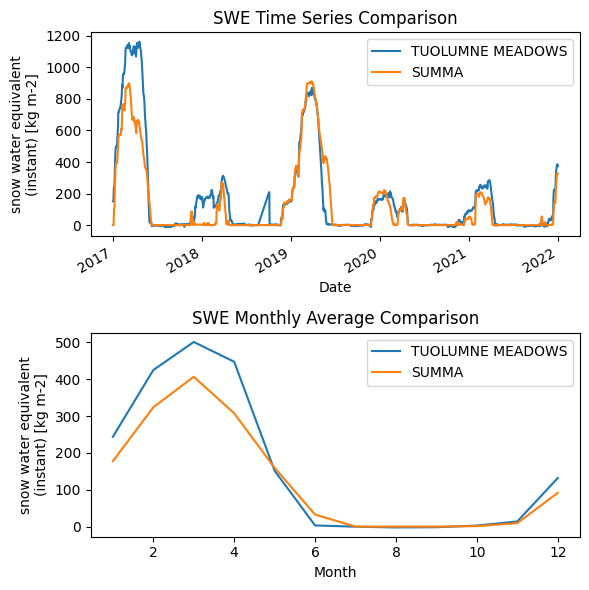

In [18]:
tuolumne_meadows_swe = tuolumne_meadows['SWE']*25.4
# filter extreme values
tuolumne_meadows_swe = tuolumne_meadows_swe[tuolumne_meadows_swe < 2000]
tuolumne_meadows_swe_monthly = tuolumne_meadows_swe.groupby(tuolumne_meadows_swe.index.month).mean()
# plot timeseries
fig, axs = plt.subplots(ncols=1, nrows=2, tight_layout=True, figsize=(6,6))
tuolumne_meadows_swe.plot(ax=axs[0], label='TUOLUMNE MEADOWS')
sim_ds['scalarSWE'].plot(ax=axs[0], label='SUMMA')
axs[0].legend()
axs[0].set_xlabel('Date')
axs[0].set_title("SWE Time Series Comparison")

# plot monthly average comparison
tuolumne_meadows_swe_monthly.plot(ax=axs[1], label='TUOLUMNE MEADOWS')
sim_ds['scalarSWE'].groupby('time.month').mean().plot(ax=axs[1], label='SUMMA')
axs[1].legend()
axs[1].set_xlabel('Month')
axs[1].set_title("SWE Monthly Average Comparison")

/home/dlhogan/miniforge3/envs/CONFLUENCE-base/lib/python3.10/site-packages/xarray/plot/dataarray_plot.py:512: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  primitive = ax.plot(xplt_val, yplt_val, *args, **kwargs)


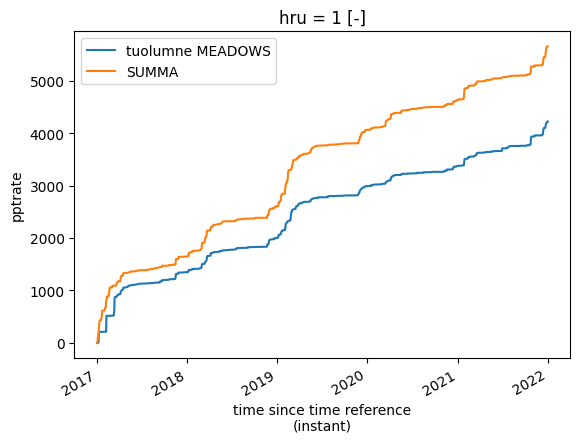

In [43]:
tuolumne_meadows_ppt = (tuolumne_meadows['PRECIPITATION']*25.4)
tuolumne_meadows_ppt = tuolumne_meadows_ppt[tuolumne_meadows_ppt < 500]
fig, ax = plt.subplots()
# ax.scatter(tuolumne_meadows_ppt.fillna(0).values, (sim_ds['pptrate']*3600).resample(time='1D').sum().sel(time=tuolumne_meadows_ppt.index.date).values, alpha=0.5)
tuolumne_meadows_ppt.cumsum().plot(ax=ax, label='tuolumne MEADOWS')
(sim_ds['pptrate']*3600).resample(time='1D').sum().cumsum().plot(ax=ax, label='SUMMA')
ax.legend()

## Summary: Lumped Basin-Scale Streamflow Simulation
This tutorial successfully demonstrated the critical scaling transition from point-scale process validation to basin-scale integrated streamflow simulation using CONFLUENCE. Through the Tuolumne River at Yosemite case study, we illustrated how the same standardized workflow framework seamlessly scales from individual site validation to watershed-scale prediction while maintaining scientific rigor and computational efficiency.

## Key Methodological Achievements
The tutorial established watershed-scale modeling capabilities by successfully transitioning from point measurements to integrated basin response through automated watershed delineation and lumped representation strategies. Spatial aggregation techniques were demonstrated through catchment-averaged characteristic development that captures essential watershed properties while maintaining computational tractability. Integrated process simulation was achieved by coupling SUMMA's process-based physics with mizuRoute streamflow routing to transform distributed runoff generation into streamflow predictions at the basin outlet.

## Scientific Process Understanding
The evaluation demonstrated CONFLUENCE's ability to simulate integrated watershed response through the successful representation of snow accumulation, melt, and runoff generation processes across elevation gradients in a mountain environment. Seasonal flow regime capture was validated through comparison with long-term Water Survey of Canada observations, showing the model's capability to represent pronounced spring freshet patterns and low-flow periods. Water balance closure was maintained through conservation of mass principles while scaling from point processes to basin-integrated streamflow generation.

## Framework Scalability Validation
This tutorial confirmed CONFLUENCE's seamless scaling capabilities by applying identical workflow principles from point validation through basin-scale prediction without requiring fundamental architectural changes. The model-agnostic preprocessing approach proved equally effective for basin-averaged forcing and validation data preparation, reinforcing the framework's broad applicability. Computational efficiency was demonstrated through lumped representation strategies that enable rapid execution suitable for calibration, uncertainty analysis, and operational applications while maintaining process-based physical realism.

This foundation in lumped basin modeling establishes the essential principles for understanding watershed-scale hydrological behavior and 
prepares for the spatial complexity introduced in semi-distributed and fully distributed modeling approaches in subsequent tutorials.

### Next Focus: Semi-Distributed Watershed Modelling 

**Ready to explore Semi-Distributed basin simulations?** → **[Tutorial 02b: Basin Scale - Semi-Distributed Watershed](./02b_basin_semi_distributed.ipynb)**